## Modeling and Analysis on Second Phishing Dataset
Import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV

Upload the dataset

In [ ]:
Web_Page_Phishing = pd.read_csv('/content/web-page-phishing.csv')
Web_Page_Phishing.head()

,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
X = Web_Page_Phishing.drop('phishing', axis=1)
y = Web_Page_Phishing['phishing']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify = y, random_state=42)
lr_model  = LogisticRegression(class_weight = 'balanced')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled,y_train)
y_pred = lr_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8610111910471623

In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.91      0.89     12743
           1       0.83      0.78      0.80      7273

    accuracy                           0.86     20016
   macro avg       0.85      0.84      0.85     20016
weighted avg       0.86      0.86      0.86     20016



In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(scores.mean())


0.8620426510192918


The test and cross validation accuracy scores are approximately 86%. The cross validation score for phishing URLs, 80%, is substantially lower than for legitimate URLs, 89%. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
logistic_regression = LogisticRegression(class_weight='balanced')
param_grid = {
    'C': [0.01, 0.1, 1, 10,100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'], # Regularization type (L1 or L2)
    'solver': ['liblinear', 'saga']     # Solvers that support both L1 and L2
}
grid_search = GridSearchCV(estimator=logistic_regression,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1,
                           n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_scaled, y_test)
print(f"Test set accuracy with best model: {test_accuracy:.4f}")
y_pred = best_model.predict(X_test_scaled)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.8621
Test set accuracy with best model: 0.8611
              precision    recall  f1-score   support

           0       0.88      0.91      0.89     12743
           1       0.83      0.78      0.80      7273

    accuracy                           0.86     20016
   macro avg       0.85      0.84      0.85     20016
weighted avg       0.86      0.86      0.86     20016



No real improvement in results. Let's do KNN Classifier now.

In [ ]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled,y_train)
y_pred = knn_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,y_pred)
accuracy


0.8842925659472423

In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     12743
           1       0.85      0.83      0.84      7273

    accuracy                           0.88     20016
   macro avg       0.88      0.87      0.87     20016
weighted avg       0.88      0.88      0.88     20016



In [ ]:
scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.8850876151573013


Metrics are better than for Logistic Regression. Both the test and cross validation accuracy score are approximately 88%. The f1 score for phishing URLs, 84%, is lower than that for legitimate URLs, 91%. Let's do hyperparameter tuning now.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
knn = KNeighborsClassifier()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_neighbors':np.arange(2,9)  # Number of neighbors (k)
}
grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)


print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


best_knn = grid_search.best_estimator_


y_pred = best_knn.predict(X_test_scaled)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the best KNN model on the test set: {accuracy:.4f}")

report = classification_report(y_test,y_pred)
print(report)

Best parameters: {'n_neighbors': np.int64(7)}
Best cross-validation score: 0.8862
Accuracy of the best KNN model on the test set: 0.8878
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     12743
           1       0.86      0.83      0.84      7273

    accuracy                           0.89     20016
   macro avg       0.88      0.88      0.88     20016
weighted avg       0.89      0.89      0.89     20016



There is a slight improvement in accuracy but f1 score for phishing URLs remains the same. Let's do Bernoulli Naive Bayes Classifier now.

In [ ]:
BN_model = BernoulliNB()
BN_model.fit(X_train,y_train)
y_pred = BN_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)


0.8206934452438049


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12743
           1       0.75      0.76      0.75      7273

    accuracy                           0.82     20016
   macro avg       0.81      0.81      0.81     20016
weighted avg       0.82      0.82      0.82     20016



In [ ]:
scores = cross_val_score(BN_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.8233847026208518


The accuracy metrics are both approximately equal to 82%. The phishing f1 score, however, is only 75% and it is subtantially less than the legitimate f1 score, 86%. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics  import accuracy_score, classification_report
bnb = BernoulliNB()
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'fit_prior': [True, False] # Whether to learn class prior probabilities or assume uniform
}
grid_search = GridSearchCV(
    estimator=bnb,
    param_grid=param_grid,
    scoring='accuracy', # Metric to optimize (e.g., accuracy, f1, recall, etc.)
    cv=5,
    verbose=1,
    n_jobs=-1 # Use all available CPU cores
)
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.3f}")
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy of the best model: {test_accuracy:.3f}")
report = classification_report(y_test,y_pred)
print(report)

Starting Grid Search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search complete.
Best parameters found: {'alpha': 10.0, 'fit_prior': False}
Best cross-validation accuracy: 0.836
Test accuracy of the best model: 0.834
              precision    recall  f1-score   support

           0       0.91      0.82      0.86     12743
           1       0.73      0.86      0.79      7273

    accuracy                           0.83     20016
   macro avg       0.82      0.84      0.83     20016
weighted avg       0.85      0.83      0.84     20016



Somewhat better test and cross validation results. The f1 score for phishing urls is significantly better. Let's do Decision Tree now.

In [ ]:
X = Web_Page_Phishing.drop('phishing', axis=1)
y = Web_Page_Phishing['phishing']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify = y, random_state=42)
dt_model = DecisionTreeClassifier(class_weight = 'balanced')
dt_model.fit(X_train,y_train)
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.8804456434852118


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.89      0.90     12743
           1       0.82      0.86      0.84      7273

    accuracy                           0.88     20016
   macro avg       0.87      0.88      0.87     20016
weighted avg       0.88      0.88      0.88     20016



In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.8834763485869331


Accuracy metrics are approximately 88%. The phishing f1 score (84%) is lower than the legitimate f1 score (90%). Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np
model = DecisionTreeClassifier(class_weight = 'balanced')
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': np.arange(3, 15)

}
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f"Best parameters: {grid_search.best_params_}")

# Print the best score achieved
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Get the best estimator (the Decision Tree model with the optimal hyperparameters)
best_dtree = grid_search.best_estimator_

# Evaluate the best model on the test set
test_accuracy = best_dtree.score(X_test, y_test)
print(f"Test set accuracy with best estimator: {test_accuracy:.4f}")

y_pred = best_dtree.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Best parameters: {'criterion': 'entropy', 'max_depth': np.int64(14)}
Best cross-validation score: 0.8844
Test set accuracy with best estimator: 0.8801
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     12743
           1       0.79      0.91      0.85      7273

    accuracy                           0.88     20016
   macro avg       0.87      0.89      0.87     20016
weighted avg       0.89      0.88      0.88     20016



No real improvement in testing and cross validation accuracy scores. Phishing f1 score is now higher (85%). Let's do Random Forest.

In [ ]:
rf_model = RandomForestClassifier(class_weight = 'balanced')
rf_model.fit(X_train,y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.887240207833733


In [ ]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.90      0.91     12743
           1       0.83      0.87      0.85      7273

    accuracy                           0.89     20016
   macro avg       0.88      0.88      0.88     20016
weighted avg       0.89      0.89      0.89     20016



In [ ]:
scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='accuracy')
print(scores.mean())

0.8895592169608507


The test and cross validation accuracy scores are approximately 89%. The f1 score for phishing URLs, 85%, is lower than that for legitimate URLs. Let's do hyperparameter tuning now.

In [ ]:
from sklearn.model_selection import GridSearchCV
model = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}
grid_search = GridSearchCV(estimator= model,
                           param_grid=param_grid,
                           cv=5,                 # Number of cross-validation folds
                           n_jobs=-1,            # Use all available CPU cores
                           verbose=2,            # Display progress messages
                           scoring='accuracy')   # Metric to optimize

grid_search.fit(X_train, y_train)

print("Best parameters found by Grid Search:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

best_rf_model = grid_search.best_estimator_
test_accuracy = best_rf_model.score(X_test, y_test)
print(f"\nAccuracy of the best model on the test set: {test_accuracy:.4f}")
y_pred = best_rf_model.predict(X_test)
report = classification_report(y_test,y_pred)
print(report)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found by Grid Search:
{'bootstrap': True, 'max_depth': 20, 'n_estimators': 300}

Best cross-validation score:
0.8912828882990228

Accuracy of the best model on the test set: 0.8872
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     12743
           1       0.81      0.89      0.85      7273

    accuracy                           0.89     20016
   macro avg       0.87      0.89      0.88     20016
weighted avg       0.89      0.89      0.89     20016



There is some improvement in the cross validation accuracy. The phishing f1 score is still the same however. Let's tabulate the results.

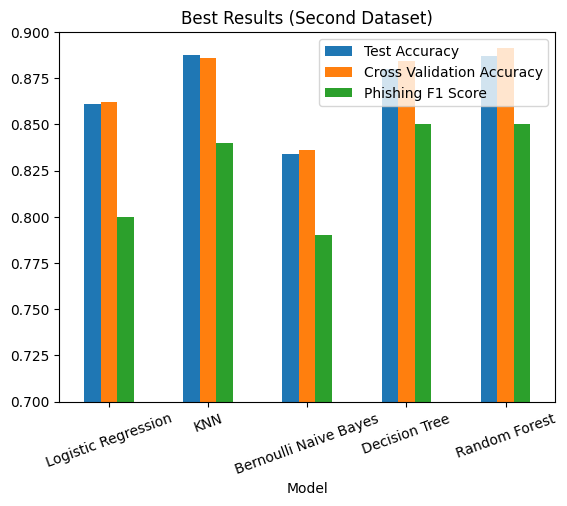

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
Table = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Bernoulli Naive Bayes','Decision Tree','Random Forest'],
    'Test Accuracy' : [0.8611,0.8878,0.834,0.8801,0.8872],
    'Cross Validation Accuracy' : [0.8621,0.8862,0.836,0.8844,0.8912828882990228],
    'Phishing F1 Score': [0.80,0.84,0.79,0.85,0.85]
})
Table.set_index('Model',inplace=True)
Table.plot(kind="bar")
plt.ylim([0.70,0.9])
plt.title("Best Results (Second Dataset)")
plt.xticks(rotation=20)
plt.show()